# PCOS Detection and Clinical Insight Analysis

In [51]:
# Basic Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Preprocessing & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [53]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


In [54]:
# Evaluation Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score


In [55]:
# Load data
data = pd.read_csv("PCOS_data.csv")

In [56]:
# fixing PCOS Column
data['PCOS'] = data['PCOS (Y/N)'].replace({'Y': 1, 'N': 0}).astype(int)

# Fixing AMH Column
data['AMH(ng/mL)'] = pd.to_numeric(data['AMH(ng/mL)'], errors='coerce')

# Filling nan values in AMH column
data['AMH(ng/mL)'] = data['AMH(ng/mL)'].fillna(data['AMH(ng/mL)'].median())


In [57]:
yn_cols = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 
           'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'Pregnant(Y/N)']

for col in yn_cols:
    if col in data.columns:
        data[col] = data[col].replace({'Y':1, 'N':0})

print("Data cleaned successfully!")
data.head()

Data cleaned successfully!


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44,PCOS
0,1,1,0,28,44.6,152.0,19.3,15,78,22,...,0,110,80,3,3,18.0,18.0,8.5,NaN,0
1,2,2,0,36,65.0,161.5,24.9,15,74,20,...,0,120,70,3,5,15.0,14.0,3.7,NaN,0
2,3,3,1,33,68.8,165.0,25.3,11,72,18,...,0,120,80,13,15,18.0,20.0,10.0,NaN,1
3,4,4,0,37,65.0,148.0,29.7,13,72,20,...,0,120,70,2,2,15.0,14.0,7.5,NaN,0
4,5,5,0,25,52.0,161.0,20.1,11,72,18,...,0,120,80,3,4,16.0,14.0,7.0,NaN,0


In [58]:
# Shape of dataset
print("Shape of dataset:", data.shape)

Shape of dataset: (541, 46)


In [59]:
# Missing values in each column
print("\nMissing values:\n")
print(data.isnull().sum())


Missing values:

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of abortions            0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)  

In [10]:
# Summary statistics (numerical features)
print("\nSummary Statistics:\n")
print(data.describe())


Summary Statistics:

           Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
count  541.000000        541.000000  541.000000  541.000000   541.000000   
mean   271.000000        271.000000    0.327172   31.430684    59.637153   
std    156.317519        156.317519    0.469615    5.411006    11.028287   
min      1.000000          1.000000    0.000000   20.000000    31.000000   
25%    136.000000        136.000000    0.000000   28.000000    52.000000   
50%    271.000000        271.000000    0.000000   31.000000    59.000000   
75%    406.000000        406.000000    1.000000   35.000000    65.000000   
max    541.000000        541.000000    1.000000   48.000000   108.000000   

       Height(Cm)          BMI  Blood Group  Pulse rate(bpm)   \
count   541.000000  541.000000   541.000000        541.000000   
mean    156.484835   24.307579    13.802218         73.247689   
std       6.033545    4.055129     1.840812          4.430285   
min     137.000000   12.400000   

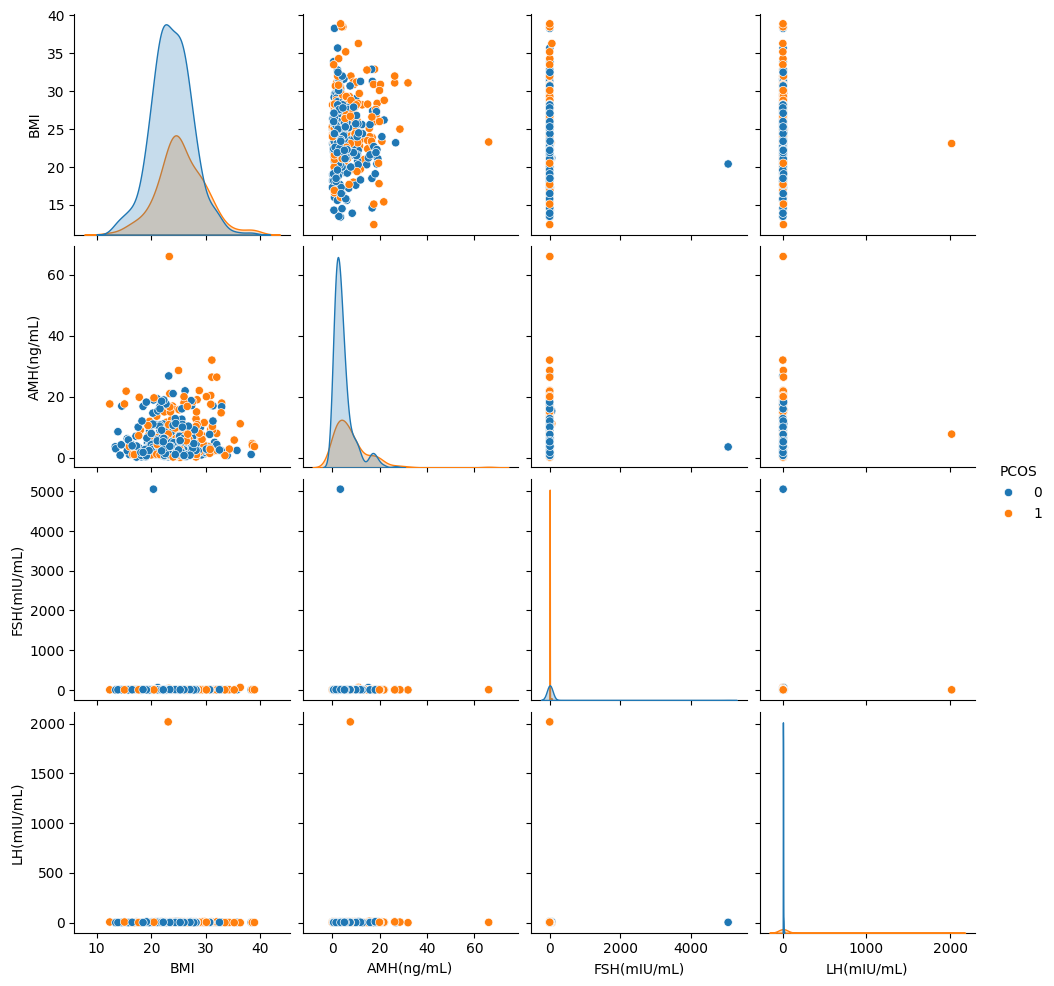

In [11]:
sns.pairplot(data[['BMI','AMH(ng/mL)','FSH(mIU/mL)','LH(mIU/mL)','PCOS']], hue='PCOS')
plt.show()


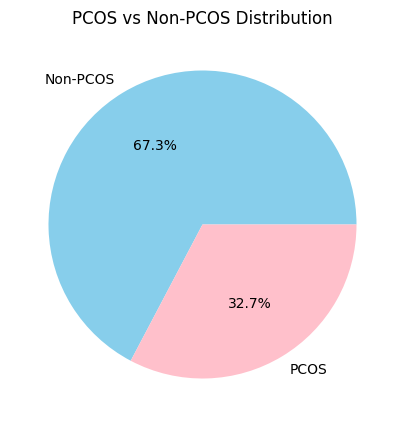

In [12]:
pcos_counts = data['PCOS'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(pcos_counts, labels=['Non-PCOS','PCOS'], autopct='%1.1f%%', colors=['skyblue','pink'])
plt.title("PCOS vs Non-PCOS Distribution")
plt.show()


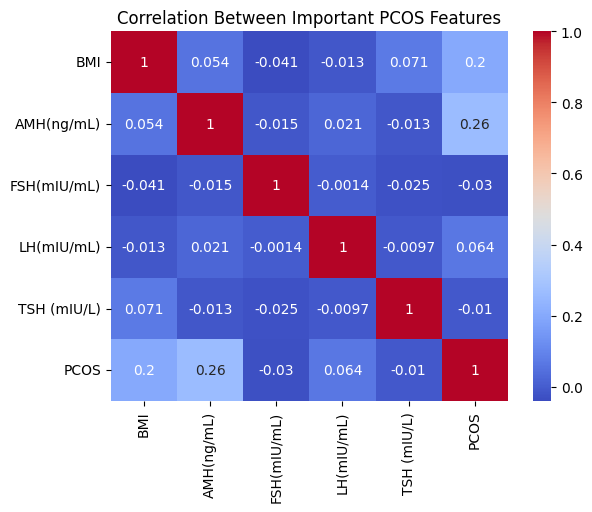

In [13]:
corr_cols = ['BMI','AMH(ng/mL)','FSH(mIU/mL)','LH(mIU/mL)','TSH (mIU/L)','PCOS']
sns.heatmap(data[corr_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Important PCOS Features")
plt.show()


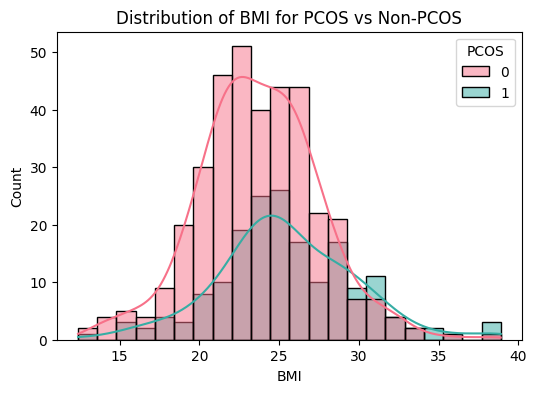

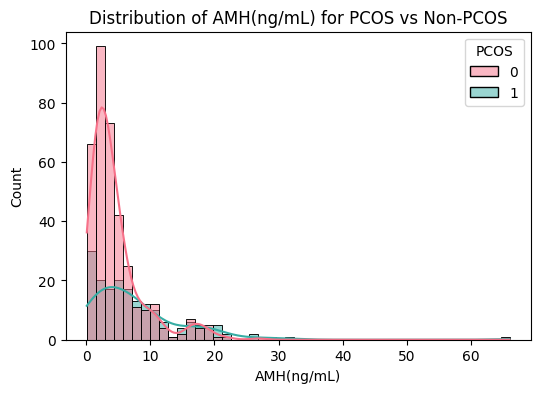

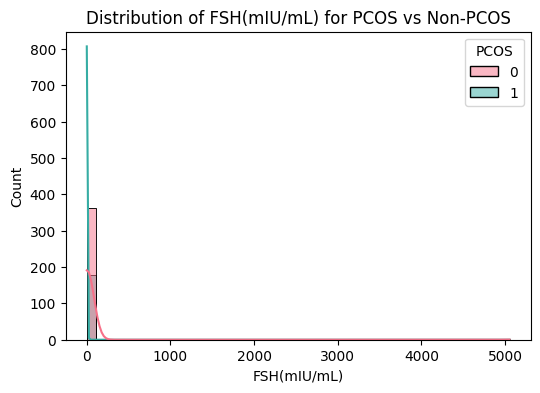

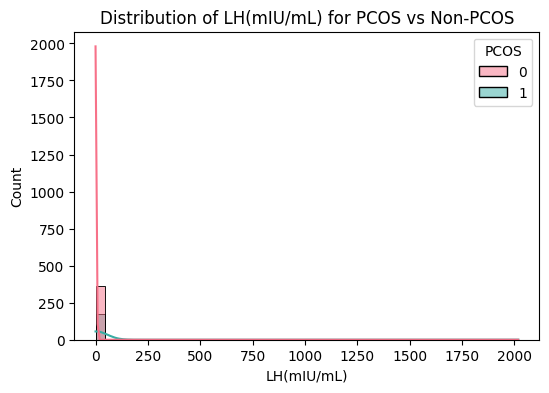

In [14]:
features_to_plot = ['BMI', 'AMH(ng/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)']

for col in features_to_plot:
    if col in data.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(data, x=col, hue='PCOS', kde=True, palette='husl')
        plt.title(f"Distribution of {col} for PCOS vs Non-PCOS")
        plt.show()


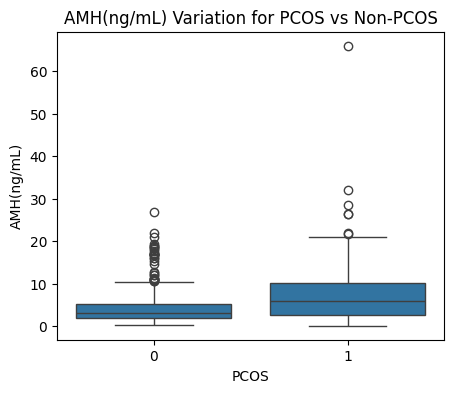

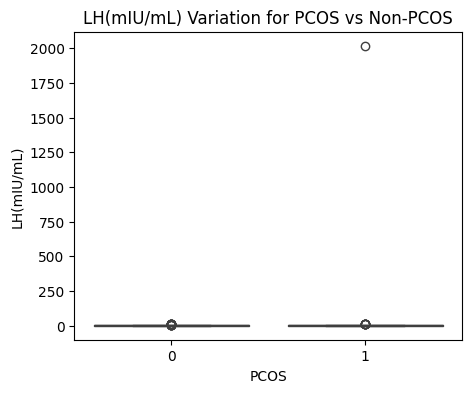

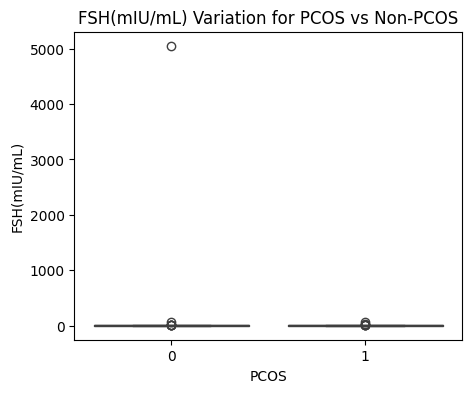

In [15]:
for col in ['AMH(ng/mL)', 'LH(mIU/mL)', 'FSH(mIU/mL)']:
    if col in data.columns:
        plt.figure(figsize=(5,4))
        sns.boxplot(data=data, x='PCOS', y=col)
        plt.title(f"{col} Variation for PCOS vs Non-PCOS")
        plt.show()
        
        


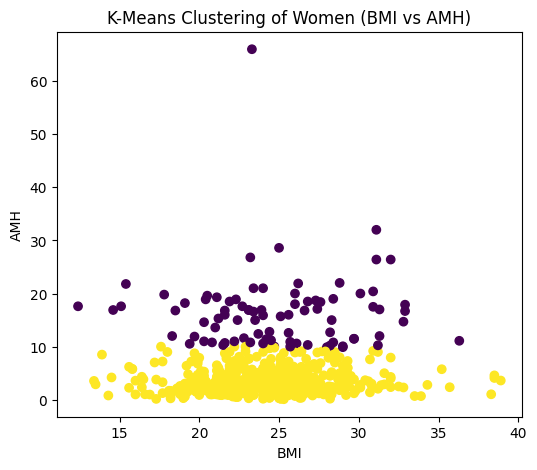

In [16]:
from sklearn.cluster import KMeans
cluster_features = ['BMI', 'AMH(ng/mL)']
df_cluster = data[cluster_features].dropna()

kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(df_cluster)

plt.figure(figsize=(6,5))
plt.scatter(df_cluster['BMI'], df_cluster['AMH(ng/mL)'], c=labels, cmap='viridis')
plt.xlabel("BMI")
plt.ylabel("AMH")
plt.title("K-Means Clustering of Women (BMI vs AMH)")
plt.show()

# Can lifestyle habits (fast food, exercise) reduce PCOS risk?

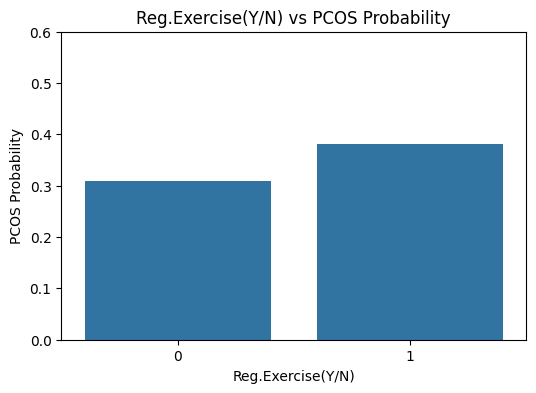

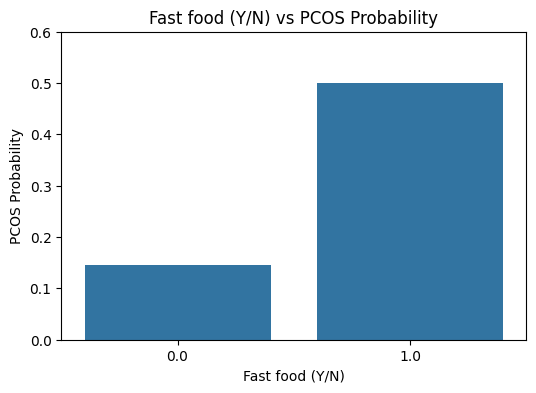

In [17]:
features = ['Reg.Exercise(Y/N)', 'Fast food (Y/N)']

for col in features:
    plt.figure(figsize=(6,4))
    sns.barplot(x=data[col], y=data['PCOS'], errorbar=None)
    plt.xlabel(col)
    plt.ylabel("PCOS Probability")
    plt.title(f"{col} vs PCOS Probability")
    plt.ylim(0, 0.6)
    plt.show()

# 1)Early PCOS Prediction (Simple Model)

In [18]:
features_q1 = [' Age (yrs)', 'BMI', 'Cycle length(days)', 'AMH(ng/mL)']

In [19]:
# Select data
X = data[features_q1]
y = data['PCOS']

In [20]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
# Predict
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7339449541284404


# 2)What symptoms affect women the most?

In [24]:
symptoms = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Pimples(Y/N)']

In [25]:
# Converting symptoms to 0/1
for col in symptoms:
    data[col] = data[col].replace({'Y':1, 'N':0})

symptom_counts = data[symptoms].sum().sort_values(ascending=False)
print(symptom_counts)


Pimples(Y/N)            265
Weight gain(Y/N)        204
Skin darkening (Y/N)    166
hair growth(Y/N)        148
dtype: int64


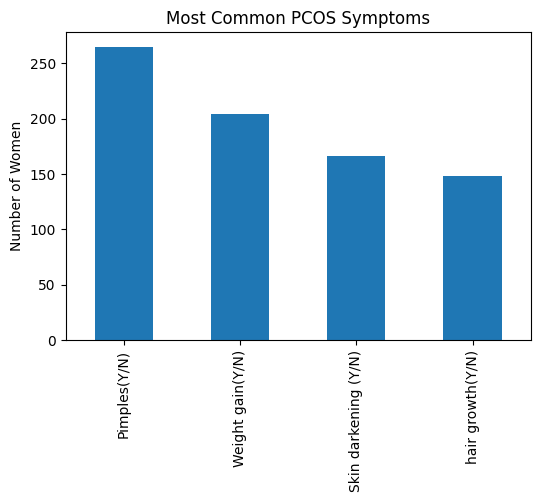

In [26]:
symptom_counts.plot(kind='bar', figsize=(6,4), title='Most Common PCOS Symptoms')
plt.ylabel("Number of Women")
plt.show()


In [27]:
symptom_features = ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Pimples(Y/N)']
X_sym = data[symptom_features]
y_sym = data['PCOS']

rf = RandomForestClassifier()
rf.fit(X_sym, y_sym)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
importance = pd.Series(rf.feature_importances_, index=symptom_features)
print("Symptom Importance:\n", importance.sort_values(ascending=False))


Symptom Importance:
 Skin darkening (Y/N)    0.332169
hair growth(Y/N)        0.309059
Weight gain(Y/N)        0.256375
Pimples(Y/N)            0.102398
dtype: float64


# 3)Which clinical features are most important for predicting PCOS?

In [29]:
clinical_features = [
    ' Age (yrs)', 'BMI', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
    'AMH(ng/mL)', 'TSH (mIU/L)', 'Waist(inch)', 'Hip(inch)', 'Waist:Hip Ratio'
]


In [30]:
# Select data
X_clin = data[clinical_features].fillna(data[clinical_features].median())
y_clin = data['PCOS']

In [31]:
# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_clin, y_clin)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [32]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=clinical_features).sort_values(ascending=False)

print("Clinical Feature Importance:\n")
print(importances)

Clinical Feature Importance:

AMH(ng/mL)         0.177984
BMI                0.118945
FSH/LH             0.114771
FSH(mIU/mL)        0.104703
LH(mIU/mL)         0.104211
TSH (mIU/L)        0.093880
 Age (yrs)         0.090295
Waist(inch)        0.071446
Hip(inch)          0.065241
Waist:Hip Ratio    0.058523
dtype: float64


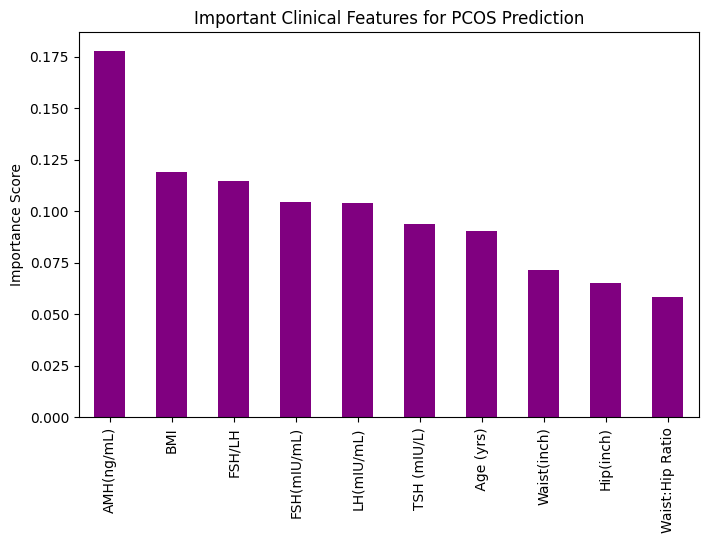

In [33]:
# Plot
plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='purple')
plt.title("Important Clinical Features for PCOS Prediction")
plt.ylabel("Importance Score")
plt.show()


# 4)Which model performs best for PCOS prediction?
(Logistic Regression vs SVM vs Random Forest)

In [34]:
better_features = [
    ' Age (yrs)', 'BMI', 'Cycle length(days)', 'AMH(ng/mL)',
    'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
    'TSH (mIU/L)', 'PRL(ng/mL)',
    'Waist(inch)', 'Hip(inch)', 'Waist:Hip Ratio',
    'Pimples(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Weight gain(Y/N)'
]

In [35]:
# Select data
X = data[better_features].fillna(data[better_features].median())
y = data['PCOS']


In [36]:
# Scale numerical values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# 1. Logistic Regression
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)


In [39]:
# 2. SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)


In [40]:
# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)


In [41]:
# Print results
print("\nImproved Model Comparison (Accuracy):")
print("Logistic Regression:", round(log_acc, 4))
print("SVM:", round(svm_acc, 4))
print("Random Forest:", round(rf_acc, 4))



Improved Model Comparison (Accuracy):
Logistic Regression: 0.8165
SVM: 0.8349
Random Forest: 0.8073


In [42]:
def check_model(model, x_train, x_test, y_train, y_test, name="Model"):
    
    # Train the model
    model.fit(x_train, y_train)
    
    #predict
    y_pred = model.predict(x_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)

    print("Accuracy:", round(acc, 4))

    # Confusion Matrix
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return acc


In [43]:
check_model(LogisticRegression(max_iter=500), X_train, X_test, y_train, y_test, "Logistic Regression")

check_model(SVC(), X_train, X_test, y_train, y_test, "SVM")

check_model(RandomForestClassifier(n_estimators=300), X_train, X_test, y_train, y_test, "Random Forest")


Accuracy: 0.8165

Confusion Matrix:
[[65  8]
 [12 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.87        73
           1       0.75      0.67      0.71        36

    accuracy                           0.82       109
   macro avg       0.80      0.78      0.79       109
weighted avg       0.81      0.82      0.81       109

Accuracy: 0.8349

Confusion Matrix:
[[66  7]
 [11 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        73
           1       0.78      0.69      0.74        36

    accuracy                           0.83       109
   macro avg       0.82      0.80      0.81       109
weighted avg       0.83      0.83      0.83       109

Accuracy: 0.8349

Confusion Matrix:
[[66  7]
 [11 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88        73


0.8348623853211009

# 5)Predict Whether a Woman Is at High Risk of Fertility Difficulty Using Hormones and Symptoms

In [44]:
df = data.copy()

df['Pregnant'] = df['Pregnant(Y/N)'].replace({'Y':1,'N':0})

df['LH_FSH_ratio'] = (df['LH(mIU/mL)']/df['FSH(mIU/mL)']).replace([np.inf,-np.inf],np.nan)
df['LH_FSH_ratio'] = df['LH_FSH_ratio'].fillna(df['LH_FSH_ratio'].median())

df['High_Risk'] = 0
df.loc[(df['AMH(ng/mL)'] < 1) | 
       (df['LH_FSH_ratio'] > 2) | 
       (df['Cycle length(days)'] > 35) | 
       (df['Cycle length(days)'] < 24), 'High_Risk'] = 1


In [45]:
features = [' Age (yrs)','BMI','AMH(ng/mL)','FSH(mIU/mL)','LH(mIU/mL)',
            'Cycle length(days)','hair growth(Y/N)','Pimples(Y/N)',
            'Weight gain(Y/N)','LH_FSH_ratio']


In [46]:
X = df[features].fillna(df[features].median())
y = df['High_Risk']


In [47]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [50]:
pred = model.predict(X_test)
print("High Risk Fertility Prediction Accuracy:", accuracy_score(y_test, pred))

High Risk Fertility Prediction Accuracy: 1.0
